# 013 — Reference-structure collapse fragilities in AvgSA

Re-express the IDA-based **collapse fragilities** of the EC8-gen2 scenario-A
reference CBFs (designed in `010`, both the 3-storey and 5-storey sets) from their
native **SA(T1)** (5%-damped spectral acceleration at the fundamental period, mm/s²)
into the two intensity measures used by the site hazard / disaggregation / MSA work:
**AvgSA_03** (geometric-mean SA over 0–3 s) and **AvgSA_06** (0–6 s). This lets
fragility and hazard be combined in a common IM.

Collapse is a linearly-scalable event, so for each record
`AvgSA_collapse = (SA(T1)_collapse / SA(T1)_record) · AvgSA_record`, and a
method-of-moments lognormal is refit in the new IM — exactly
`standes.analysis.ida.convert_ida_collapse_imls` + `collapse_fragility_from_imls`.

**Inputs**
- Fragility IDA outputs from `010`: `<reference_structures_dc2_scA>/<tag>/mdof/ida_femap695/`
  (`collapse_fragility.json`, `ida_results.pickle`, `record_*/ida_log_record_*.json`).
- Design base-shear coefficient `Vb_coeff` from the `010` design dataset
  (`dc2_scA_reference_dataset`) — read, **not** recomputed.

**Outputs** — three JSON fragilities per structure in
`data_processed/09_reference_structure_fragility_curves/ec8_gen2_scA/`,
named `{tag}_collapsefragility_{im}.json` for `im ∈ {SA, AvgSA_03, AvgSA_06}`,
each with a `<file>.manifest.json` provenance sidecar so only structures whose
inputs changed are re-converted.

> **Run order.** Requires `010`'s FEMA-P695 IDA to have been run (the
> `ida_femap695/` folders must exist). Structures without IDA output are skipped
> with a message. The SA→AvgSA conversion logic itself was validated against the
> equivalent `E:/03_wp1pt4pt1_dc2_sdof_fitting/3s_cbf_dc2_*` IDA outputs.


## 0. Setup & parameters

In [1]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy.stats import lognorm

from phd_project.config import config
from phd_project.scripts.cache_utils import fingerprint, write_manifest
from standes.analysis.ida import (
    collect_ida_results, collect_record_logs,
    convert_ida_collapse_imls, collapse_fragility_from_imls,
)
from standes.intensitymeasures import SpectralAcceleration, avgsa_03, avgsa_06
from standes.groundmotion import load_ground_motion_from_json

cfg = config.load_config()

In [2]:
# ----------------------------------------------------------------------------
# PARAMETERS
# ----------------------------------------------------------------------------
# Root of the reference-structure IDA folders written by nb 010. Per structure the
# FEMA P695 IDA lives at IDA_ROOT/<tag>/mdof/ida_femap695/.
IDA_ROOT = Path(cfg["analysis_data"]["reference_structures_dc2_scA"])

# Design dataset (nb 010) that carries the base-shear coefficient Vb_coeff.
REF_DATASET = Path(cfg["proc_data"]["dc2_scA_reference_dataset"])

# Where the converted fragilities are written.
OUT_DIR = Path(cfg["proc_data"]["ec8_gen2_scA_fragility_curves"])
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Force a full re-conversion even when the provenance manifest still matches.
FORCE_RECOMPUTE = False

GRAVITY = 9810.0  # mm/s^2 -- IML units of the IDA, used only to plot the x-axis in g

# Target intensity measures for the conversion (SA(T1) is handled separately as the
# native IM: its fragility is copied through unchanged).
AVGSA_IMS = {"AvgSA_03": avgsa_03(), "AvgSA_06": avgsa_06()}
IM_ORDER = ["SA", "AvgSA_03", "AvgSA_06"]  # panel order

print(f"IDA_ROOT   = {IDA_ROOT}")
print(f"REF_DATASET= {REF_DATASET}")
print(f"OUT_DIR    = {OUT_DIR}")

IDA_ROOT   = D:\06_reference_structures_dc2_scA
REF_DATASET= C:\Users\clemettn\Documents\phd\data_processed\08_casestudy_structure_datasets\ec8_gen2_dc2_scA_reference_cbfs.pickle
OUT_DIR    = C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\ec8_gen2_scA_reference


## 1. Reference structures & design base-shear coefficient

Take the reference structures from the `010` design dataset and read
their design base-shear coefficient `Vb_coeff = Vb/Wt` straight from it (no
recomputation). Each structure's IDA folder is `IDA_ROOT/<tag>/mdof/ida_femap695`.

In [3]:
designs = pd.read_pickle(REF_DATASET)
designs = designs.sort_values("Vb_coeff").reset_index(drop=True)

TAGS = designs["name"].tolist()
VB_COEFF = dict(zip(designs["name"], designs["Vb_coeff"]))
N_STOREYS = dict(zip(designs["name"], designs["n_storeys"]))

def ida_folder(tag: str) -> Path:
    return IDA_ROOT / tag / "mdof" / "ida_femap695"

designs["ida_exists"] = [ida_folder(t).is_dir() for t in TAGS]
print(f"{len(TAGS)} reference structures; {int(designs['ida_exists'].sum())} have IDA output on disk")
designs[["name", "n_storeys", "design_baseshear", "Vb", "Wt", "Vb_coeff", "ida_exists"]]

18 reference structures; 9 have IDA output on disk


,name,n_storeys,design_baseshear,Vb,Wt,Vb_coeff,ida_exists
0,5s_dc2_scA_13,5,1.333924e+05,1.333924e+05,5178600.0,0.025758,False
1,3s_dc2_scA_13,3,7.990584e+04,7.990584e+04,3061800.0,0.026098,True
2,3s_dc2_scA_20,3,8.338487e+04,8.338487e+04,3061800.0,0.027234,True
3,5s_dc2_scA_30,5,1.640687e+05,1.640687e+05,5178600.0,0.031682,False
4,5s_dc2_scA_20,5,1.640687e+05,1.640687e+05,5178600.0,0.031682,False
5,3s_dc2_scA_30,3,1.339760e+05,1.339760e+05,3061800.0,0.043757,True
6,5s_dc2_scA_40,5,3.335414e+05,3.335414e+05,5178600.0,0.064408,False
7,5s_dc2_scA_50,5,4.414656e+05,4.414656e+05,5178600.0,0.085248,False
8,3s_dc2_scA_40,3,2.633529e+05,2.633529e+05,3061800.0,0.086012,True
9,5s_dc2_scA_60,5,5.444992e+05,5.444992e+05,5178600.0,0.105144,False


## 2. Provenance-aware JSON cache

`json_load_or_compute` mirrors `cache_utils.load_or_compute` but writes JSON: it
reuses the cached fragility only when its `<file>.manifest.json` sidecar still
matches the current input fingerprint, and otherwise re-converts and rewrites both.
This is the "only repeat conversions for fragility curves that have changed" logic —
a changed `ida_results.pickle` (i.e. a re-run IDA) invalidates the cache.

In [4]:
def _np_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    raise TypeError(f"not JSON serialisable: {type(o)}")


def _changed_inputs(cached: dict, current: dict) -> list[str]:
    """Names of inputs whose content hash differs between two fingerprints."""
    return [name for name in sorted(set(cached) | set(current))
            if cached.get(name, {}).get("hash") != current.get(name, {}).get("hash")]


def json_load_or_compute(artifact_fp: Path, fp_dict: dict, compute_fn,
                         force: bool = False, input_paths: dict | None = None):
    # Return (fragility_dict, status) where status is 'cached' or 'computed'.
    # When a cached artifact is present but stale, print the file path of each
    # input that changed (from input_paths) before recomputing.
    artifact_fp = Path(artifact_fp)
    manifest_fp = artifact_fp.with_name(artifact_fp.name + ".manifest.json")
    input_paths = input_paths or {}

    if not force and artifact_fp.is_file() and manifest_fp.is_file():
        cached = json.load(open(manifest_fp)).get("inputs", {})
        changed = _changed_inputs(cached, fp_dict)
        if not changed:
            with open(artifact_fp) as f:
                return json.load(f), "cached"
        for name in changed:
            where = input_paths.get(name)
            where = str(where) if where is not None else f"input '{name}' (no file path)"
            print(f"[stale] {artifact_fp.name}: recomputing -- changed input: {where}")

    result = compute_fn()
    artifact_fp.parent.mkdir(parents=True, exist_ok=True)
    with open(artifact_fp, "w") as f:
        json.dump(result, f, indent=2, default=_np_default)
    write_manifest(artifact_fp, fp_dict)
    return result, "computed" 

## 3. Convert each structure

For each structure: read its IDA results and per-record logs, recover the design
period `T1` (and hence the native `SpectralAcceleration(T1)`) from the IDA intensity
measure, load the ground-motion records, and convert the collapse IMLs into each
AvgSA. The native SA fragility is copied through from the IDA's own
`collapse_fragility.json`. `gravity_factor` is left at 1 — it cancels in the
`SA→AvgSA` ratio.

In [5]:
def parse_T1(logs: dict) -> float:
    im_str = next(iter(logs.values()))["intensity_measure"]
    return float(re.search(r"period=([0-9.eE+-]+)", im_str).group(1))


def process_structure(tag: str, force: bool = FORCE_RECOMPUTE):
    fol = ida_folder(tag)
    if not fol.is_dir():
        print(f"[skip] {tag}: no IDA output at {fol}")
        return None

    ida_results = collect_ida_results(fol)
    logs = collect_record_logs(fol)
    original_im = SpectralAcceleration(parse_T1(logs))
    gm_records = {n: load_ground_motion_from_json(Path(logs[n]["record_path"]))
                  for n in ida_results}

    out = {}

    # --- native SA(T1): copy the IDA's own collapse fragility through unchanged ---
    src_frag = fol / "collapse_fragility.json"
    sa_fp = OUT_DIR / f"{tag}_collapsefragility_SA.json"
    sa_inputs = fingerprint(source_frag=src_frag)
    out["SA"], sa_status = json_load_or_compute(
        sa_fp, sa_inputs, lambda: json.load(open(src_frag)), force=force,
        input_paths={"source_frag": src_frag})

    # --- AvgSA conversions ---
    ida_results_fp = fol / "ida_results.pickle"
    record_logs_fp = fol / "record_logs.json"
    statuses = {"SA": sa_status}
    for name, new_im in AVGSA_IMS.items():
        fp = OUT_DIR / f"{tag}_collapsefragility_{name}.json"
        inputs = fingerprint(
            ida_results=ida_results_fp,
            record_logs=record_logs_fp,
            im_periods=np.asarray(new_im.periods),
        )

        def _convert(new_im=new_im):
            conv = convert_ida_collapse_imls(ida_results, gm_records, original_im, new_im)
            return collapse_fragility_from_imls(conv.values()).asdict()

        out[name], statuses[name] = json_load_or_compute(
            fp, inputs, _convert, force=force,
            input_paths={"ida_results": ida_results_fp, "record_logs": record_logs_fp})

    print(f"[ok]   {tag}: " + ", ".join(f"{k}={v}" for k, v in statuses.items()))
    return out


results = {}
for tag in TAGS:
    res = process_structure(tag)
    if res is not None:
        results[tag] = res

print(f"\nconverted {len(results)}/{len(TAGS)} structures -> {OUT_DIR}")

[skip] 5s_dc2_scA_13: no IDA output at D:\06_reference_structures_dc2_scA\5s_dc2_scA_13\mdof\ida_femap695
[stale] 3s_dc2_scA_13_collapsefragility_SA.json: recomputing -- changed input: D:\06_reference_structures_dc2_scA\3s_dc2_scA_13\mdof\ida_femap695\collapse_fragility.json
[stale] 3s_dc2_scA_13_collapsefragility_AvgSA_03.json: recomputing -- changed input: D:\06_reference_structures_dc2_scA\3s_dc2_scA_13\mdof\ida_femap695\ida_results.pickle
[stale] 3s_dc2_scA_13_collapsefragility_AvgSA_03.json: recomputing -- changed input: D:\06_reference_structures_dc2_scA\3s_dc2_scA_13\mdof\ida_femap695\record_logs.json
[stale] 3s_dc2_scA_13_collapsefragility_AvgSA_06.json: recomputing -- changed input: D:\06_reference_structures_dc2_scA\3s_dc2_scA_13\mdof\ida_femap695\ida_results.pickle
[stale] 3s_dc2_scA_13_collapsefragility_AvgSA_06.json: recomputing -- changed input: D:\06_reference_structures_dc2_scA\3s_dc2_scA_13\mdof\ida_femap695\record_logs.json
[ok]   3s_dc2_scA_13: SA=computed, AvgSA_03=

## 4. Collapse fragilities by intensity measure

One row of three panels — native **SA(T1)**, **AvgSA_03**, **AvgSA_06** — per unique
storey count, so the 3-storey and 5-storey reference sets are shown separately.
Within each panel the structures' collapse fragilities (lognormal CDFs) are coloured
by their design base-shear coefficient `Vb_coeff = Vb/Wt` (sequential *viridis*, one
shared colorbar spanning all heights), so the collapse-capacity ladder from lightly
to heavily designed structures is comparable across every IM and both heights. The
x-axis is in units of g (`median / g`).

saved C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\ec8_gen2_scA_reference\collapse_fragilities_by_im.png


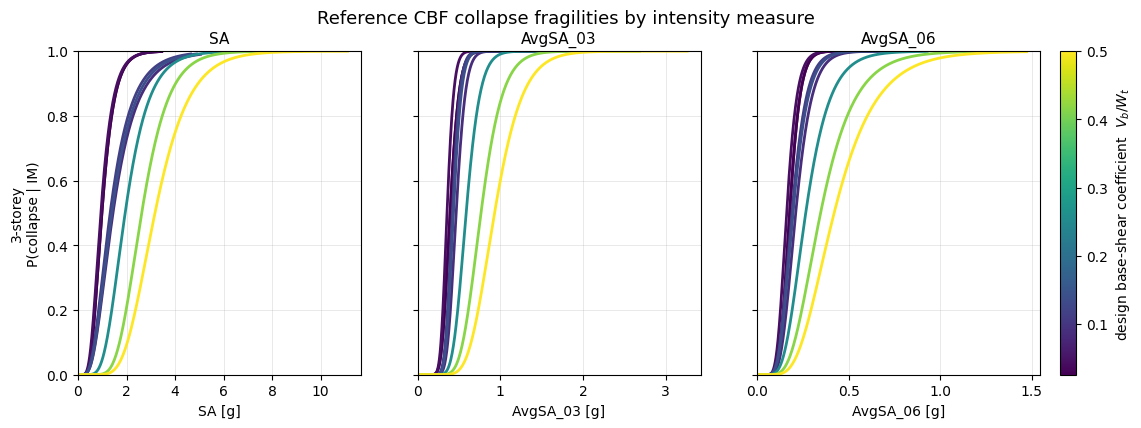

In [6]:
if not results:
    print("no converted fragilities to plot (run nb 010's IDA first)")
else:
    plot_tags = [t for t in TAGS if t in results]
    # Shared global viridis scale over all heights, so colours are comparable
    # between the storey-count rows.
    vbs = np.array([VB_COEFF[t] for t in plot_tags])
    norm = Normalize(vmin=vbs.min(), vmax=vbs.max())
    cmap = cm.viridis

    # One row of 3 IM panels per unique storey count (ascending).
    storey_counts = sorted({N_STOREYS[t] for t in plot_tags})
    nrows = len(storey_counts)

    fig, axes = plt.subplots(nrows, 3, figsize=(13, 4.2 * nrows),
                             sharey=True, squeeze=False)
    for r, ns in enumerate(storey_counts):
        row_tags = [t for t in plot_tags if N_STOREYS[t] == ns]
        for c, im in enumerate(IM_ORDER):
            ax = axes[r][c]
            for tag in row_tags:
                frag = results[tag][im]
                median_g = frag["median"] / GRAVITY
                x = np.linspace(1e-3, median_g * 3.5, 400)
                y = lognorm.cdf(x, s=frag["dispersion"], scale=median_g)
                ax.plot(x, y, lw=2, color=cmap(norm(VB_COEFF[tag])))
            if r == 0:
                ax.set_title(im, fontsize=11)
            if r == nrows - 1:
                ax.set_xlabel(f"{im} [g]")
            ax.set_xlim(left=0)
            ax.set_ylim(0, 1)
            ax.grid(True, lw=0.5, alpha=0.4)
        axes[r][0].set_ylabel(f"{ns}-storey\nP(collapse | IM)")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label(r"design base-shear coefficient  $V_b/W_t$")

    fig.suptitle("Reference CBF collapse fragilities by intensity measure", fontsize=13)
    fig_path = OUT_DIR / "collapse_fragilities_by_im.png"
    fig.savefig(fig_path, dpi=200, bbox_inches="tight")
    print(f"saved {fig_path}")
    plt.show()

### Fragility parameters

Median and dispersion of each structure's lognormal collapse fragility, in every
intensity measure. Rows are structures; columns are a two-level index (IM →
`median` / `dispersion`). Medians are reported in **g** (`median / g`);
dispersions are the dimensionless lognormal $\beta$.

In [7]:
if not results:
    print("no converted fragilities to summarise (run nb 010's IDA first)")
    summary = pd.DataFrame()
else:
    rows = {}
    for tag in [t for t in TAGS if t in results]:
        row = {}
        for im in IM_ORDER:
            frag = results[tag][im]
            row[(im, "median")] = frag["median"] / GRAVITY  # g
            row[(im, "dispersion")] = frag["dispersion"]
        rows[tag] = row

    summary = pd.DataFrame.from_dict(rows, orient="index")
    summary.columns = pd.MultiIndex.from_tuples(summary.columns, names=["IM", "parameter"])
    summary = summary[IM_ORDER]  # enforce panel/IM column order
    summary.index.name = "structure"

    with pd.option_context("display.float_format", lambda v: f"{v:.3f}"):
        print(summary.to_string())

_ = summary.to_csv(cfg["proc_data"]["dc2_scA_reference_collapse_fc_summary"])

IM                 SA            AvgSA_03            AvgSA_06           
parameter      median dispersion   median dispersion   median dispersion
structure                                                               
3s_dc2_scA_13   0.985      0.406    0.393      0.216    0.178      0.255
3s_dc2_scA_20   0.985      0.406    0.393      0.216    0.178      0.255
3s_dc2_scA_30   0.941      0.422    0.356      0.181    0.161      0.278
3s_dc2_scA_40   1.443      0.537    0.466      0.191    0.211      0.327
3s_dc2_scA_50   1.326      0.527    0.420      0.176    0.190      0.327
3s_dc2_scA_60   1.395      0.526    0.433      0.178    0.196      0.330
3s_dc2_scA_70   1.944      0.396    0.587      0.226    0.266      0.389
3s_dc2_scA_100  2.625      0.333    0.767      0.264    0.347      0.417
3s_dc2_scA_120  3.173      0.347    0.931      0.283    0.421      0.425


### Collapse median vs design base-shear coefficient

Collapse median (in g) against the design base-shear coefficient $V_b/W_t$, one
panel per intensity measure. Each storey count is a separate line (blue = 3-storey,
red = 5-storey) with circular black-edged markers, joined in ascending $V_b/W_t$
order to show the capacity trend.

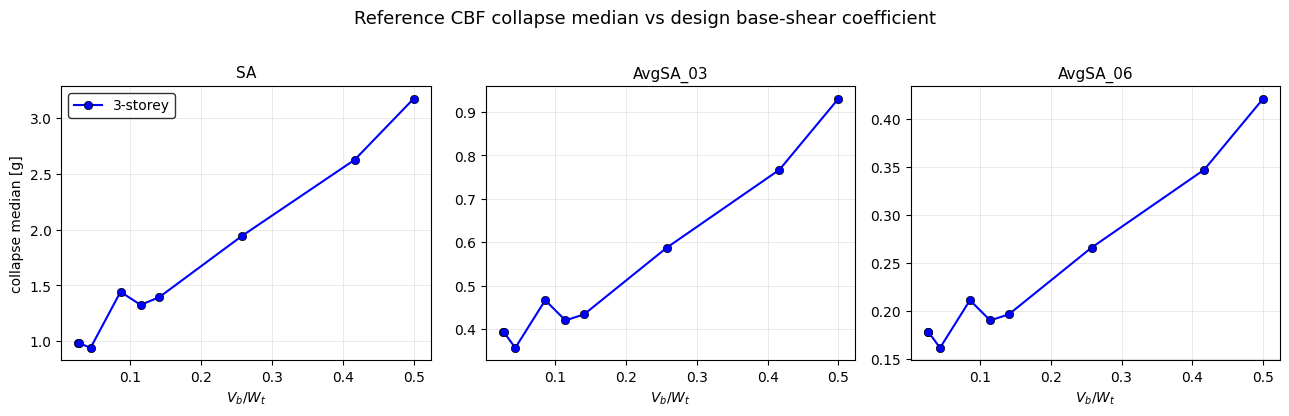

In [8]:
# Solid colour per storey count (ascending): blue, red, green.
STOREY_COLORS = ["b", "r", "g"]


def plot_param_vs_vbcoeff(param: str, ylabel: str, title: str):
    """3-panel scatter of a fragility parameter ('median'/'dispersion') vs Vb_coeff,
    with one line + circular markers per storey count."""
    if not results:
        print("no converted fragilities to plot (run nb 010's IDA first)")
        return
    plot_tags = [t for t in TAGS if t in results]
    storey_counts = sorted({N_STOREYS[t] for t in plot_tags})
    color_of = {ns: STOREY_COLORS[i % len(STOREY_COLORS)]
                for i, ns in enumerate(storey_counts)}

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)
    fig.patch.set_facecolor("white")
    for ax, im in zip(axes, IM_ORDER):
        for ns in storey_counts:
            tags_h = [t for t in plot_tags if N_STOREYS[t] == ns]
            vbs_h = np.array([VB_COEFF[t] for t in tags_h])
            order = np.argsort(vbs_h)
            vbs_h = vbs_h[order]
            vals_h = np.array([summary.loc[t, (im, param)] for t in tags_h])[order]
            ax.plot(vbs_h, vals_h, "-o", color=color_of[ns],
                    markeredgecolor="k", markeredgewidth=0.5, markersize=6,
                    lw=1.5, label=f"{ns}-storey")
        ax.set_title(im, fontsize=11)
        ax.set_xlabel(r"$V_b/W_t$")
        ax.set_facecolor("white")
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("k")
        ax.grid(True, lw=0.5, alpha=0.4)
    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=True, edgecolor="k")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    return fig


fig_med = plot_param_vs_vbcoeff(
    "median", "collapse median [g]",
    "Reference CBF collapse median vs design base-shear coefficient")
if fig_med is not None:
    fig_med.savefig(OUT_DIR / "collapse_median_vs_vbcoeff.png", dpi=200, bbox_inches="tight")
    plt.show()

### Collapse dispersion vs design base-shear coefficient

The same layout for the lognormal dispersion $\beta$ — one panel per intensity
measure, plotted against $V_b/W_t$.

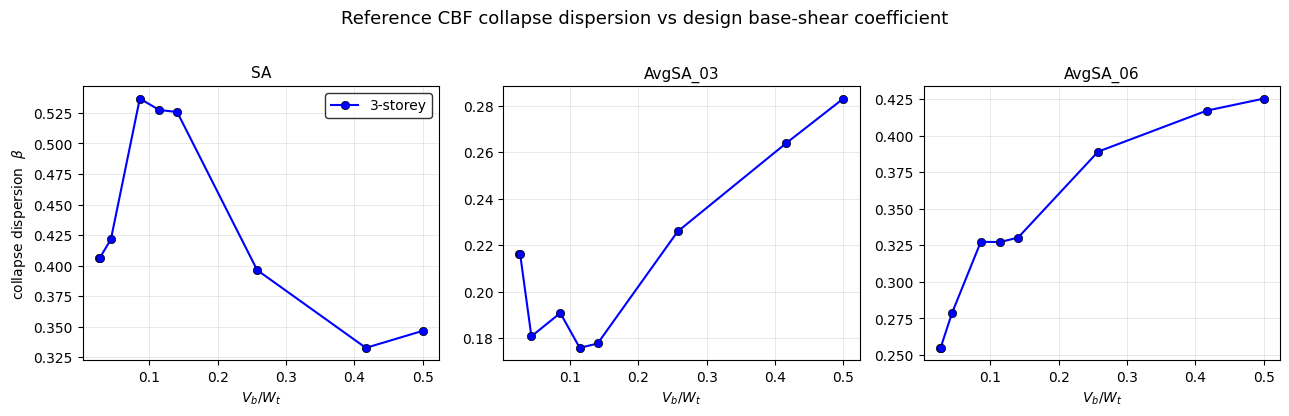

In [9]:
fig_disp = plot_param_vs_vbcoeff(
    "dispersion", r"collapse dispersion  $\beta$",
    "Reference CBF collapse dispersion vs design base-shear coefficient")
if fig_disp is not None:
    fig_disp.savefig(OUT_DIR / "collapse_dispersion_vs_vbcoeff.png", dpi=200, bbox_inches="tight")
    plt.show()